# 🚀 Complete OCR Training Pipeline - Google Colab

## 📋 Features:
- ✅ Auto-mount Google Drive
- ✅ Auto-find & extract ZIP dataset
- ✅ Full CRNN + biLSTM + CTC training
- ✅ **Auto-save checkpoints to Drive** (won't lose progress!)
- ✅ Auto-resume from checkpoint if interrupted
- ✅ Save best model to Drive
- ✅ Training history & visualization

---

## 1️⃣ Install Dependencies

In [ ]:
# Install required packages
!pip install torch torchvision pandas pillow tqdm -q

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4
GPU Memory: 14.6 GB


## 2️⃣ Mount Google Drive

In [ ]:
from google.colab import drive
import os
import shutil

# Mount Google Drive
print("🔗 Mounting Google Drive...")
drive.mount('/content/drive')
print("✅ Google Drive mounted successfully!")
print(f"   Drive location: /content/drive/MyDrive")

# Create a directory for saving checkpoints in Drive
DRIVE_CHECKPOINT_DIR = "/content/drive/MyDrive/ocr_training_checkpoints"
os.makedirs(DRIVE_CHECKPOINT_DIR, exist_ok=True)
print(f"\n📁 Checkpoint directory created: {DRIVE_CHECKPOINT_DIR}")

🔗 Mounting Google Drive...
Mounted at /content/drive
✅ Google Drive mounted successfully!
   Drive location: /content/drive/MyDrive

📁 Checkpoint directory created: /content/drive/MyDrive/ocr_training_checkpoints


## 3️⃣ Find Dataset ZIP in Google Drive

In [ ]:
import zipfile

print("🔍 Searching for dataset ZIP in Google Drive...")
print("="*70)

# Search for ZIP files
found_zips = []
search_paths = [
    "/content/drive/MyDrive/WaterMeter_Project/M4_Training/data/m4_ocr_dataset_black_digits.zip",
]

for base_path in search_paths:
    if os.path.exists(base_path):
        for root, dirs, files in os.walk(base_path):
            for file in files:
                if file.endswith('.zip') and 'm4_ocr' in file.lower():
                    full_path = os.path.join(root, file)
                    size_mb = os.path.getsize(full_path) / (1024 * 1024)
                    found_zips.append((full_path, size_mb))
            if len(found_zips) > 10:  # Limit search
                break
    if found_zips:
        break

if found_zips:
    print(f"\n✅ Found {len(found_zips)} ZIP file(s):\n")
    for i, (path, size) in enumerate(found_zips, 1):
        print(f"  {i}. {path}")
        print(f"     Size: {size:.1f} MB")

    # Use first found ZIP
    ZIP_FILE = found_zips[0][0]
    print(f"\n🎯 Selected: {ZIP_FILE}")
else:
    # Manual input
    print("\n❌ No ZIP files found automatically.")
    print("\nPlease enter the path to your ZIP file:")
    print("Example: /content/drive/MyDrive/WaterMeter_Project/M4_Training/data/m4_ocr_dataset_black_digits.zip")
    ZIP_FILE = input("\nZIP file path: ").strip()

    if not os.path.exists(ZIP_FILE):
        raise FileNotFoundError(f"ZIP file not found: {ZIP_FILE}")

print(f"\n✅ ZIP file ready: {ZIP_FILE}")

🔍 Searching for dataset ZIP in Google Drive...

❌ No ZIP files found automatically.

Please enter the path to your ZIP file:
Example: /content/drive/MyDrive/WaterMeter_Project/M4_Training/data/m4_ocr_dataset_black_digits.zip

ZIP file path: /content/drive/MyDrive/WaterMeter_Project/M4_Training/data/m4_ocr_dataset_black_digits.zip

✅ ZIP file ready: /content/drive/MyDrive/WaterMeter_Project/M4_Training/data/m4_ocr_dataset_black_digits.zip


## 4️⃣ Extract Dataset to Colab Local Storage

In [ ]:
# Extraction directory
# Chúng ta sẽ giải nén thẳng vào một thư mục tên là 'dataset' cho dễ quản lý
EXTRACT_TO = "/content/dataset"

print(f"📦 Extracting dataset...")
if os.path.exists(EXTRACT_TO):
    shutil.rmtree(EXTRACT_TO)
os.makedirs(EXTRACT_TO, exist_ok=True)

try:
    with zipfile.ZipFile(ZIP_FILE, 'r') as zip_ref:
        # Giải nén vào folder /content/dataset
        zip_ref.extractall(EXTRACT_TO)
    print(f"✅ Extraction completed to: {EXTRACT_TO}")
except Exception as e:
    print(f"❌ Extraction error: {e}")

# Tự động xác định xem có folder lồng bên trong không
# Nếu sau khi giải nén có 1 folder con duy nhất, chúng ta sẽ trỏ vào đó
content_list = os.listdir(EXTRACT_TO)
if len(content_list) == 1 and os.path.isdir(os.path.join(EXTRACT_TO, content_list[0])):
    DATA_DIR = os.path.join(EXTRACT_TO, content_list[0])
else:
    DATA_DIR = EXTRACT_TO

IMAGES_DIR = os.path.join(DATA_DIR, "images")
LABELS_FILE = os.path.join(DATA_DIR, "labels.csv")

print(f"🎯 Final Data Path: {DATA_DIR}")
print(f"📊 Labels File: {LABELS_FILE}")

📦 Extracting dataset...
✅ Extraction completed to: /content/dataset
🎯 Final Data Path: /content/dataset/m4_ocr_dataset_black_digits
📊 Labels File: /content/dataset/m4_ocr_dataset_black_digits/labels.csv


## 5️⃣ Import Libraries & Define Configuration

In [ ]:
import os
import pandas as pd
import numpy as np
from pathlib import Path
from typing import List, Tuple, Dict
import copy
import json
from datetime import datetime

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image
import matplotlib.pyplot as plt
from tqdm import tqdm

# Set random seeds
torch.manual_seed(42)
np.random.seed(42)

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [ ]:
import os

# ====================== CONFIGURATION (Bản đầy đủ) ======================
class Config:
    # 1. Đường dẫn dữ liệu (Lấy từ kết quả giải nén thành công của bạn)
    DATA_DIR = DATA_DIR
    IMAGES_DIR = IMAGES_DIR
    LABELS_FILE = LABELS_FILE

    # 2. Đường dẫn lưu trữ trên Google Drive
    DRIVE_CHECKPOINT_DIR = DRIVE_CHECKPOINT_DIR
    CHECKPOINT_FILE = os.path.join(DRIVE_CHECKPOINT_DIR, "training_checkpoint.pth")
    BEST_MODEL_FILE = os.path.join(DRIVE_CHECKPOINT_DIR, "best_model.pth")
    HISTORY_FILE = os.path.join(DRIVE_CHECKPOINT_DIR, "training_history.json")

    # 3. Tham số mô hình
    IMG_HEIGHT = 64
    IMG_WIDTH = 256
    NUM_CHANNELS = 1
    NUM_CLASSES = 11  # 0-9 + blank character

    # 4. Tham số huấn luyện
    BATCH_SIZE = 32
    NUM_EPOCHS = 50
    LEARNING_RATE = 0.001
    WEIGHT_DECAY = 1e-5
    BLANK_IDX = 10
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

    # 5. TẦN SUẤT LƯU (Đây là phần bị thiếu gây ra lỗi AttributeError)
    SAVE_FREQ = 5      # Cứ mỗi 5 epoch sẽ lưu checkpoint một lần
    BACKUP_FREQ = 10   # Cứ mỗi 10 epoch sẽ tạo một bản backup riêng trên Drive

    # 6. Bản đồ ký tự
    CHAR_MAP = "0123456789"
    LABEL_TO_CHAR = {i: c for i, c in enumerate(CHAR_MAP)}
    CHAR_TO_LABEL = {c: i for i, c in enumerate(CHAR_MAP)}

print(f"✅ Config đã được cập nhật đầy đủ tham số!")
print(f"💾 Tần suất lưu checkpoint: {Config.SAVE_FREQ} epochs/lần")
print(f"💻 Thiết bị sử dụng: {Config.DEVICE}")
if Config.DEVICE.type == 'cuda':
    print(f"   Tên GPU: {torch.cuda.get_device_name(0)}")
else:
    print(f"   Vui lòng chuyển đổi sang runtime GPU (ví dụ: T4) để tăng tốc độ huấn luyện.")

✅ Config đã được cập nhật đầy đủ tham số!
💾 Tần suất lưu checkpoint: 5 epochs/lần
💻 Thiết bị sử dụng: cuda
   Tên GPU: Tesla T4


## 6️⃣ Define Dataset Class

In [ ]:
class OCRDataset(Dataset):
    """OCR Dataset with string label handling"""

    def __init__(self, labels_file: str, images_dir: str, transform=None):
        self.images_dir = Path(images_dir)
        self.transform = transform

        # Load and process labels
        self.data_frame = pd.read_csv(labels_file)

        # CRITICAL: Ensure labels are strings
        self.data_frame['text'] = self.data_frame['text'].astype(str)
        self.data_frame['filename'] = self.data_frame['filename'].astype(str)

        print(f"Loaded {len(self.data_frame)} samples")

    def __len__(self):
        return len(self.data_frame)

    def __getitem__(self, idx):
        row = self.data_frame.iloc[idx]

        # Load image
        img_path = self.images_dir / row['filename']
        image = Image.open(img_path).convert('L')

        # Get label as string
        label = str(row['text'])

        # Apply transforms
        if self.transform:
            image = self.transform(image)

        # Encode label
        label_encoded = [Config.CHAR_TO_LABEL[char] for char in label]
        label_length = len(label_encoded)

        return {
            'image': image,
            'label': label,
            'label_encoded': torch.LongTensor(label_encoded),
            'label_length': torch.LongTensor([label_length])
        }

print("✅ Dataset class defined!")

✅ Dataset class defined!


## 7️⃣ Define CRNN Model

In [ ]:
class CRNN(nn.Module):
    """CRNN with CNN backbone and biLSTM decoder"""

    def __init__(self, num_classes=11, num_channels=1, img_height=64):
        super(CRNN, self).__init__()

        # CNN Feature Extractor
        self.cnn = nn.Sequential(
            nn.Conv2d(num_channels, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, padding=1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(256, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(), nn.MaxPool2d((2, 1), (2, 1)),
            nn.Conv2d(512, 512, 3, padding=1), nn.BatchNorm2d(512), nn.ReLU(),
        )

        # TỰ ĐỘNG TÍNH TOÁN RNN INPUT SIZE
        # Chiều cao sau CNN = IMG_HEIGHT / 16 (do có 3 lớp pool 2 và 1 lớp pool (2,1))
        h_out = img_height // 16
        self.rnn_input_size = 512 * h_out  # Sẽ là 2048 nếu H=64, hoặc 1024 nếu H=32

        self.hidden_size = 256
        self.rnn = nn.LSTM(
            self.rnn_input_size,
            self.hidden_size,
            num_layers=2,
            bidirectional=True,
            batch_first=True,
            dropout=0.3
        )

        self.fc = nn.Linear(self.hidden_size * 2, num_classes)

    def forward(self, x):
        conv = self.cnn(x)
        b, c, h, w = conv.size()
        conv = conv.permute(0, 3, 1, 2).contiguous().view(b, w, c * h)
        rnn_out, _ = self.rnn(conv)
        out = self.fc(rnn_out).permute(1, 0, 2)
        return out

print("✅ Model architecture fixed for IMG_HEIGHT!")

✅ Model architecture fixed for IMG_HEIGHT!


## 8️⃣ Define Utility Functions

In [ ]:
def collate_fn(batch):
    """Custom collate function for CTC"""
    images = torch.stack([item['image'] for item in batch])
    labels = torch.cat([item['label_encoded'] for item in batch])
    label_lengths = torch.cat([item['label_length'] for item in batch])
    label_strings = [item['label'] for item in batch]
    input_lengths = torch.LongTensor([Config.IMG_WIDTH // 8 for _ in batch])

    return {
        'images': images,
        'labels': labels,
        'label_lengths': label_lengths,
        'input_lengths': input_lengths,
        'label_strings': label_strings
    }


def decode_predictions(predictions, label_to_char, blank_idx):
    """Decode CTC predictions to strings"""
    pred_indices = predictions.argmax(dim=-1).permute(1, 0).cpu().numpy()

    decoded = []
    for pred in pred_indices:
        chars = []
        prev = None
        for idx in pred:
            if idx != blank_idx and idx != prev:
                chars.append(label_to_char[idx])
            prev = idx
        decoded.append(''.join(chars))

    return decoded


def calculate_accuracy(predictions, targets, label_to_char, blank_idx):
    """Calculate exact match accuracy"""
    decoded = decode_predictions(predictions, label_to_char, blank_idx)
    return sum(1 for pred, target in zip(decoded, targets) if pred == target) / len(targets)


def save_checkpoint(model, optimizer, scheduler, epoch, history, best_val_loss, is_best=False):
    """Save checkpoint to Google Drive"""
    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict(),
        'history': history,
        'best_val_loss': best_val_loss,
        'timestamp': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
    }

    # Save latest checkpoint
    torch.save(checkpoint, Config.CHECKPOINT_FILE)

    # Save best model
    if is_best:
        torch.save(checkpoint, Config.BEST_MODEL_FILE)

    # Save history as JSON
    with open(Config.HISTORY_FILE, 'w') as f:
        json.dump(history, f, indent=2)


def load_checkpoint(model, optimizer=None, scheduler=None):
    """Load checkpoint from Google Drive"""
    if not os.path.exists(Config.CHECKPOINT_FILE):
        print("No checkpoint found. Starting from scratch.")
        return 0, {'train_loss': [], 'val_loss': [], 'val_accuracy': []}, float('inf')

    print(f"📂 Loading checkpoint from: {Config.CHECKPOINT_FILE}")
    checkpoint = torch.load(Config.CHECKPOINT_FILE, map_location=Config.DEVICE)

    model.load_state_dict(checkpoint['model_state_dict'])

    if optimizer and checkpoint['optimizer_state_dict']:
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

    if scheduler and checkpoint['scheduler_state_dict']:
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

    epoch = checkpoint['epoch']
    history = checkpoint.get('history', {'train_loss': [], 'val_loss': [], 'val_accuracy': []})
    best_val_loss = checkpoint.get('best_val_loss', float('inf'))

    print(f"✅ Checkpoint loaded!")
    print(f"   Epoch: {epoch}")
    print(f"   Best val loss: {best_val_loss:.4f}")
    print(f"   Timestamp: {checkpoint.get('timestamp', 'Unknown')}")

    return epoch, history, best_val_loss

print("✅ Utility functions defined!")

✅ Utility functions defined!


## 9️⃣ Prepare Dataset & DataLoaders

In [ ]:
# Define transforms
transform = transforms.Compose([
    transforms.Resize((Config.IMG_HEIGHT, Config.IMG_WIDTH)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

# Load dataset
print("Loading dataset...")
full_dataset = OCRDataset(
    labels_file=Config.LABELS_FILE,
    images_dir=Config.IMAGES_DIR,
    transform=transform
)

# Split dataset (90-10)
train_size = int(0.9 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(
    full_dataset, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"\nDataset split:")
print(f"  Training: {len(train_dataset)} samples")
print(f"  Validation: {len(val_dataset)} samples")

Loading dataset...
Loaded 6193 samples

Dataset split:
  Training: 5573 samples
  Validation: 620 samples


In [ ]:
# Section 9: DataLoader
train_loader = DataLoader(
    train_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False # Tự động bật/tắt
)

val_loader = DataLoader(
    val_dataset,
    batch_size=Config.BATCH_SIZE,
    shuffle=False, # No need to shuffle validation data
    collate_fn=collate_fn,
    num_workers=2,
    pin_memory=True if torch.cuda.is_available() else False
)

## 🔟 Initialize Model & Load Checkpoint

In [ ]:
# Initialize model
model = CRNN(
    num_classes=Config.NUM_CLASSES,
    num_channels=Config.NUM_CHANNELS,
    img_height=Config.IMG_HEIGHT  # Thêm dòng này để khớp với Config
).to(Config.DEVICE)

# Print model info
total_params = sum(p.numel() for p in model.parameters())
print(f"\n🔧 Model initialized!")
print(f"   Total parameters: {total_params:,}")


🔧 Model initialized!
   Total parameters: 10,217,483


In [ ]:
# Define loss and optimizer
criterion = nn.CTCLoss(blank=Config.BLANK_IDX, zero_infinity=True)

optimizer = optim.Adam(
    model.parameters(),
    lr=Config.LEARNING_RATE,
    weight_decay=Config.WEIGHT_DECAY
)

# Sửa lại dòng này bằng cách bỏ tham số verbose
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=5
)

# Try to load checkpoint
start_epoch, history, best_val_loss = load_checkpoint(
    model, optimizer, scheduler
)

print(f"\nStarting from epoch: {start_epoch + 1}")
print(f"Best validation loss so far: {best_val_loss:.4f}")

No checkpoint found. Starting from scratch.

Starting from epoch: 1
Best validation loss so far: inf


## 1️⃣1️⃣ Training Functions

In [ ]:
def train_epoch(model, dataloader, criterion, optimizer, device):
    """Train for one epoch"""
    model.train()
    total_loss = 0.0
    total_samples = 0

    pbar = tqdm(dataloader, desc="Training")
    for batch in pbar:
        images = batch['images'].to(device)
        labels = batch['labels'].to(device)
        label_lengths = batch['label_lengths'].to(device)
        input_lengths = batch['input_lengths'].to(device)

        optimizer.zero_grad()
        predictions = model(images)
        log_probs = predictions.log_softmax(dim=-1)
        loss = criterion(log_probs, labels, input_lengths, label_lengths)

        loss.backward()
        optimizer.step()

        batch_size = images.size(0)
        total_loss += loss.item() * batch_size
        total_samples += batch_size

        pbar.set_postfix({'loss': loss.item()})

    return total_loss / total_samples


def validate(model, dataloader, criterion, device, label_to_char, blank_idx):
    """Validate the model"""
    model.eval()
    total_loss = 0.0
    total_samples = 0
    all_predictions = []
    all_targets = []

    with torch.no_grad():
        for batch in tqdm(dataloader, desc="Validating"):
            images = batch['images'].to(device)
            labels = batch['labels'].to(device)
            label_lengths = batch['label_lengths'].to(device)
            input_lengths = batch['input_lengths'].to(device)

            predictions = model(images)
            log_probs = predictions.log_softmax(dim=-1)
            loss = criterion(log_probs, labels, input_lengths, label_lengths)

            batch_size = images.size(0)
            total_loss += loss.item() * batch_size
            total_samples += batch_size

            all_predictions.append(predictions)
            all_targets.extend(batch['label_strings'])

    all_predictions = torch.cat(all_predictions, dim=1)
    accuracy = calculate_accuracy(all_predictions, all_targets, label_to_char, blank_idx)

    return total_loss / total_samples, accuracy

print("✅ Training functions defined!")

✅ Training functions defined!


## 1️⃣2️⃣ START TRAINING 🚀

In [ ]:
# ====================== TRAINING LOOP ======================
print("\n" + "="*70)
print("🚀 STARTING TRAINING")
print("="*70)
print(f"\nConfiguration:")
print(f"  Device: {Config.DEVICE}")
print(f"  Epochs: {Config.NUM_EPOCHS}")
print(f"  Starting from: epoch {start_epoch + 1}")
print(f"  Checkpoints saved to: {Config.DRIVE_CHECKPOINT_DIR}")
print(f"  Auto-save frequency: Every {Config.SAVE_FREQ} epochs")
print("\n" + "="*70)

try:
    for epoch in range(start_epoch + 1, Config.NUM_EPOCHS + 1):
        print(f"\n{'='*70}")
        print(f"EPOCH {epoch}/{Config.NUM_EPOCHS}")
        print(f"{'='*70}")

        # Train
        train_loss = train_epoch(
            model, train_loader, criterion, optimizer, Config.DEVICE
        )

        # Validate
        val_loss, val_accuracy = validate(
            model, val_loader, criterion, Config.DEVICE,
            Config.LABEL_TO_CHAR, Config.BLANK_IDX
        )

        # Update scheduler
        scheduler.step(val_loss)

        # Record history
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_accuracy'].append(val_accuracy)

        # Print results
        print(f"\n📊 Results:")
        print(f"  Train Loss: {train_loss:.4f}")
        print(f"  Val Loss: {val_loss:.4f}")
        print(f"  Val Accuracy: {val_accuracy:.4f}")

        # Check if best
        is_best = val_loss < best_val_loss
        if is_best:
            best_val_loss = val_loss
            print(f"  🎉 NEW BEST MODEL! (val_loss: {val_loss:.4f})")

        # Save checkpoint
        if epoch % Config.SAVE_FREQ == 0 or is_best:
            print(f"  💾 Saving checkpoint to Google Drive...")
            save_checkpoint(
                model, optimizer, scheduler, epoch, history, best_val_loss, is_best
            )
            print(f"  ✅ Checkpoint saved!")
            print(f"     Location: {Config.CHECKPOINT_FILE}")
            if is_best:
                print(f"     Best model: {Config.BEST_MODEL_FILE}")

        # Backup to Drive periodically
        if epoch % Config.BACKUP_FREQ == 0:
            backup_file = os.path.join(
                Config.DRIVE_CHECKPOINT_DIR,
                f"backup_epoch_{epoch}.pth"
            )
            shutil.copy(Config.CHECKPOINT_FILE, backup_file)
            print(f"  📦 Backup created: {backup_file}")

    print("\n" + "="*70)
    print("✅ TRAINING COMPLETED!")
    print("="*70)
    print(f"\nFinal Results:")
    print(f"  Best validation loss: {best_val_loss:.4f}")
    print(f"  Final validation accuracy: {history['val_accuracy'][-1]:.4f}")
    print(f"\n📁 All checkpoints saved to: {Config.DRIVE_CHECKPOINT_DIR}")
    print(f"   - Latest checkpoint: {Config.CHECKPOINT_FILE}")
    print(f"   - Best model: {Config.BEST_MODEL_FILE}")
    print(f"   - Training history: {Config.HISTORY_FILE}")

except KeyboardInterrupt:
    print("\n" + "="*70)
    print("⚠️  Training interrupted by user!")
    print("="*70)
    print(f"\n💾 Saving checkpoint before exit...")
    save_checkpoint(
        model, optimizer, scheduler, epoch - 1, history, best_val_loss, is_best
    )
    print(f"✅ Checkpoint saved! You can resume training later.")
    print(f"   Location: {Config.CHECKPOINT_FILE}")

except Exception as e:
    print(f"\n❌ Error during training: {e}")
    import traceback
    traceback.print_exc()
    print(f"\n💾 Attempting to save checkpoint...")
    try:
        save_checkpoint(
            model, optimizer, scheduler, epoch - 1, history, best_val_loss, is_best
        )
        print(f"✅ Checkpoint saved despite error!")
    except:
        print(f"❌ Could not save checkpoint.")


🚀 STARTING TRAINING

Configuration:
  Device: cuda
  Epochs: 50
  Starting from: epoch 1
  Checkpoints saved to: /content/drive/MyDrive/ocr_training_checkpoints
  Auto-save frequency: Every 5 epochs


EPOCH 1/50


Validating: 100%|██████████| 20/20 [00:01<00:00, 12.05it/s]



📊 Results:
  Train Loss: 3.1926
  Val Loss: 2.9335
  Val Accuracy: 0.0000
  🎉 NEW BEST MODEL! (val_loss: 2.9335)
  💾 Saving checkpoint to Google Drive...
  ✅ Checkpoint saved!
     Location: /content/drive/MyDrive/ocr_training_checkpoints/training_checkpoint.pth
     Best model: /content/drive/MyDrive/ocr_training_checkpoints/best_model.pth

EPOCH 2/50


Validating: 100%|██████████| 20/20 [00:01<00:00, 14.90it/s]



📊 Results:
  Train Loss: 2.8817
  Val Loss: 2.9166
  Val Accuracy: 0.0000
  🎉 NEW BEST MODEL! (val_loss: 2.9166)
  💾 Saving checkpoint to Google Drive...
  ✅ Checkpoint saved!
     Location: /content/drive/MyDrive/ocr_training_checkpoints/training_checkpoint.pth
     Best model: /content/drive/MyDrive/ocr_training_checkpoints/best_model.pth

EPOCH 3/50


...


📊 Results:
  Train Loss: 0.0002
  Val Loss: 0.1090
  Val Accuracy: 0.9694

EPOCH 49/50


Validating: 100%|██████████| 20/20 [00:01<00:00, 12.52it/s]



📊 Results:
  Train Loss: 0.0002
  Val Loss: 0.1098
  Val Accuracy: 0.9694

EPOCH 50/50


Validating: 100%|██████████| 20/20 [00:01<00:00, 14.73it/s]



📊 Results:
  Train Loss: 0.0002
  Val Loss: 0.1101
  Val Accuracy: 0.9694
  💾 Saving checkpoint to Google Drive...
  ✅ Checkpoint saved!
     Location: /content/drive/MyDrive/ocr_training_checkpoints/training_checkpoint.pth
  📦 Backup created: /content/drive/MyDrive/ocr_training_checkpoints/backup_epoch_50.pth

✅ TRAINING COMPLETED!

Final Results:
  Best validation loss: 0.0962
  Final validation accuracy: 0.9694

📁 All checkpoints saved to: /content/drive/MyDrive/ocr_training_checkpoints
   - Latest checkpoint: /content/drive/MyDrive/ocr_training_checkpoints/training_checkpoint.pth
   - Best model: /content/drive/MyDrive/ocr_training_checkpoints/best_model.pth
   - Training history: /content/drive/MyDrive/ocr_training_checkpoints/training_history.json


## 1️⃣3️⃣ Plot Training History

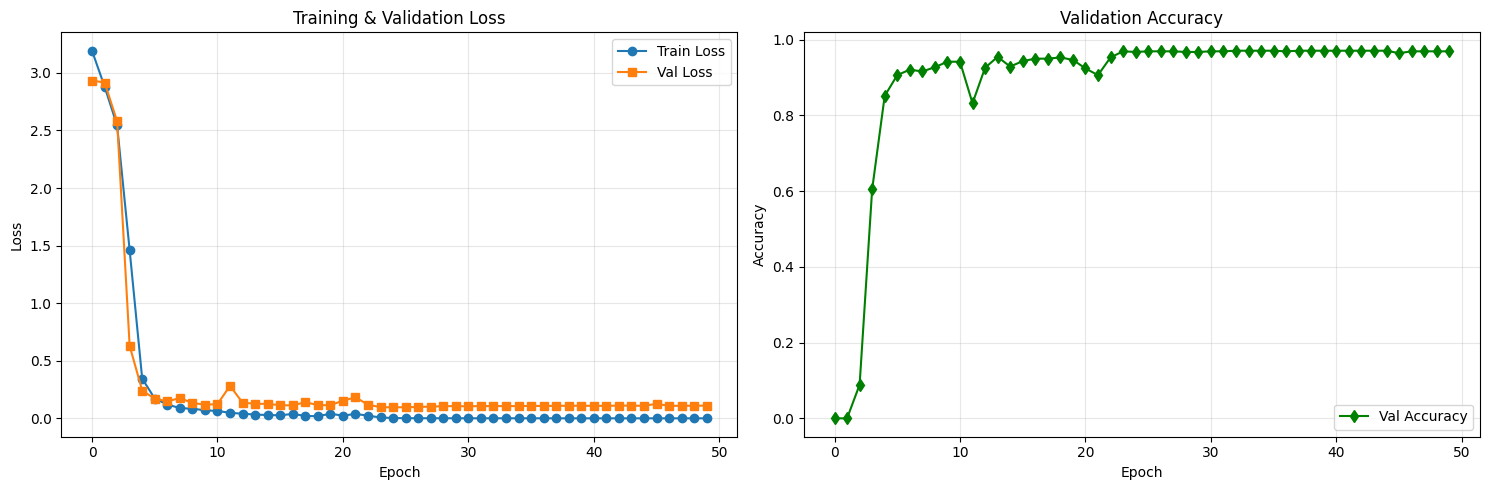


📊 Final Statistics:
  Total epochs trained: 50
  Final train loss: 0.0002
  Final val loss: 0.1101
  Final val accuracy: 0.9694
  Best val loss: 0.0962


In [ ]:
# Load history from file (in case of restart)
if os.path.exists(Config.HISTORY_FILE):
    with open(Config.HISTORY_FILE, 'r') as f:
        history = json.load(f)

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Loss plot
axes[0].plot(history['train_loss'], label='Train Loss', marker='o')
axes[0].plot(history['val_loss'], label='Val Loss', marker='s')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy plot
axes[1].plot(history['val_accuracy'], label='Val Accuracy', color='green', marker='d')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Validation Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n📊 Final Statistics:")
print(f"  Total epochs trained: {len(history['train_loss'])}")
print(f"  Final train loss: {history['train_loss'][-1]:.4f}")
print(f"  Final val loss: {history['val_loss'][-1]:.4f}")
print(f"  Final val accuracy: {history['val_accuracy'][-1]:.4f}")
print(f"  Best val loss: {min(history['val_loss']):.4f}")

## 1️⃣4️⃣ Make Predictions

In [ ]:
def predict(image_path, model, device):
    """Make prediction on a single image"""
    model.eval()

    # Load and preprocess
    transform = transforms.Compose([
        transforms.Resize((Config.IMG_HEIGHT, Config.IMG_WIDTH)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5], std=[0.5])
    ])

    image = Image.open(image_path).convert('L')
    image = transform(image).unsqueeze(0).to(device)

    # Predict
    with torch.no_grad():
        predictions = model(image)

    # Decode
    decoded = decode_predictions(predictions, Config.LABEL_TO_CHAR, Config.BLANK_IDX)

    return decoded[0]

# Load best model
if os.path.exists(Config.BEST_MODEL_FILE):
    print(f"Loading best model from: {Config.BEST_MODEL_FILE}")
    checkpoint = torch.load(Config.BEST_MODEL_FILE, map_location=Config.DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"✅ Best model loaded! (epoch {checkpoint['epoch']})")
else:
    print(f"Using current model state.")

Loading best model from: /content/drive/MyDrive/ocr_training_checkpoints/best_model.pth
✅ Best model loaded! (epoch 25)


In [ ]:
# Test on random validation samples
import random
from IPython.display import Image, display

num_samples = 10
correct = 0

print(f"Testing on {num_samples} random validation samples...\n")

for i in range(num_samples):
    idx = random.randint(0, len(val_dataset) - 1)
    sample = val_dataset[idx]
    sample_data = val_dataset.dataset.data_frame.iloc[idx]

    img_path = Path(Config.IMAGES_DIR) / sample_data['filename']
    true_label = sample_data['text']

    pred_label = predict(str(img_path), model, Config.DEVICE)

    is_correct = true_label == pred_label
    if is_correct:
        correct += 1

    status = "✅" if is_correct else "❌"
    print(f"{status} True: {true_label} | Pred: {pred_label}")

print(f"\nAccuracy: {correct}/{num_samples} ({correct/num_samples:.2%})")

Testing on 10 random validation samples...



AttributeError: type object 'Image' has no attribute 'open'

## 1️⃣5️⃣ Checkpoint Management & Info

In [ ]:
# List all checkpoints in Drive
print(f"\n📁 Checkpoints in Google Drive:")
print(f"="*70)

checkpoint_files = [f for f in os.listdir(Config.DRIVE_CHECKPOINT_DIR) if f.endswith('.pth')]

if checkpoint_files:
    for f in sorted(checkpoint_files):
        file_path = os.path.join(Config.DRIVE_CHECKPOINT_DIR, f)
        size_mb = os.path.getsize(file_path) / (1024 * 1024)
        mtime = datetime.fromtimestamp(os.path.getmtime(file_path))
        print(f"  {f:40} ({size_mb:6.2f} MB) - {mtime}")
else:
    print("  No checkpoints found.")

print(f"\n📊 Training history file:")
if os.path.exists(Config.HISTORY_FILE):
    print(f"  {Config.HISTORY_FILE}")
    print(f"  Size: {os.path.getsize(Config.HISTORY_FILE) / 1024:.2f} KB")
else:
    print(f"  No history file found.")


📁 Checkpoints in Google Drive:
  backup_epoch_10.pth                      (116.98 MB) - 2026-03-06 19:23:55
  backup_epoch_20.pth                      (116.98 MB) - 2026-03-06 19:26:30
  backup_epoch_30.pth                      (116.98 MB) - 2026-03-06 19:29:00
  backup_epoch_40.pth                      (116.98 MB) - 2026-03-06 19:31:28
  backup_epoch_50.pth                      (116.98 MB) - 2026-03-06 19:33:56
  best_model.pth                           (116.98 MB) - 2026-03-06 19:27:46
  training_checkpoint.pth                  (116.98 MB) - 2026-03-06 19:33:55

📊 Training history file:
  /content/drive/MyDrive/ocr_training_checkpoints/training_history.json
  Size: 3.66 KB


## 1️⃣6️⃣ Resume Training (Optional)

**If you want to continue training later**, just run all cells from the beginning.
The notebook will automatically:
- Load the latest checkpoint from Google Drive
- Resume from the last epoch
- Continue improving the model

No data loss - everything is saved to your Google Drive!

## ✅ Summary

### What was accomplished:
1. ✅ Connected to Google Drive
2. ✅ Found & extracted dataset ZIP
3. ✅ Built CRNN + biLSTM model
4. ✅ Trained with CTC Loss
5. ✅ **Auto-saved checkpoints to Drive** (won't lose progress!)
6. ✅ Can resume training anytime

### Files saved to Google Drive:
- `training_checkpoint.pth` - Latest checkpoint (auto-updated)
- `best_model.pth` - Best model based on validation loss
- `training_history.json` - Training metrics history
- `backup_epoch_N.pth` - Periodic backups

### To resume training later:
1. Open this notebook in Colab
2. Run all cells (Ctrl+F9 or Runtime → Run all)
3. Training will resume from the last checkpoint!

### To use the trained model:
```python
# Load from Drive
checkpoint = torch.load('/content/drive/MyDrive/ocr_training_checkpoints/best_model.pth')
model.load_state_dict(checkpoint['model_state_dict'])

# Make predictions
result = predict('path/to/image.jpg', model, device)
```

---

**🎉 Congratulations! Your model is trained and safely saved to Google Drive!**